# 3 ЛАБОРАТОРНАЯ РАБОТА ПО ФРЕЙМВОРКАМ ДЛЯ ML
### Выполнена студентом 102 группы, Дубчаком Александром.

# 1. Загрузка и первичная проверка видео

Перед извлечением кадров необходимо загрузить исходное видео и проверить его основные параметры: количество кадров, FPS, ширину, высоту и длительность. Это нужно, чтобы понять размер данных и выбрать частоту извлечения кадров.

In [1]:
import cv2
import os

In [2]:
video_path = "input_video/input.mp4"

cap = cv2.VideoCapture(video_path)

frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
duration = frame_count / fps

print("Количество кадров:", frame_count)
print("FPS:", fps)
print("Ширина кадра:", width)
print("Высота кадра:", height)
print("Длительность видео, секунд:", round(duration, 2))

cap.release()

Количество кадров: 301
FPS: 30.0
Ширина кадра: 1920
Высота кадра: 1080
Длительность видео, секунд: 10.03


После выполнения кода было установлено, что видео содержит 301 кадр, частота кадров составляет 30 FPS, размер кадра — 1920×1080 пикселей, а длительность видео — около 10 секунд. Так как видео короткое, на следующем этапе можно извлекать все кадры без пропуска.

Теперь выполним декодирование видео: последовательно прочитаем каждый кадр из input.mp4 и сохраним его как отдельное изображение. Так как видео короткое и содержит 301 кадр, будем сохранять все кадры без пропуска:

In [3]:
import cv2
import os

video_path = "input_video/input.mp4"
frames_dir = "frames"

os.makedirs(frames_dir, exist_ok=True)

cap = cv2.VideoCapture(video_path)

frame_id = 0

while True:
    ret, frame = cap.read()
    
    if not ret:
        break
    
    frame_name = f"frame_{frame_id:05d}.jpg"
    frame_path = os.path.join(frames_dir, frame_name)
    
    cv2.imwrite(frame_path, frame)
    
    frame_id += 1

cap.release()

print("Сохранено кадров:", frame_id)

Сохранено кадров: 301


В результате декодирования исходного видео было сохранено 301 изображение в формате JPEG. Каждый кадр находится в папке `frames` и далее будет использоваться для получения bounding boxes и формирования датасета для обучения модели детекции объектов.
Кадры были сохранены в формате JPEG, так как изображения являются кадрами реального видео. JPEG позволяет уменьшить размер датасета, а небольшие потери качества не являются критичными для задачи детекции объектов.

# 2. Получение bounding boxes разными методами

На этом этапе получим координаты bounding boxes для объектов на кадрах. 

Для получения bounding boxes используем публичную модель компьютерного зрения YOLOv8 из библиотеки Ultralytics. Дополнительно был реализуем метод выделения объектов на основе контуров OpenCV для последующего сравнительного анализа.

YOLO использовалась как основной метод детекции объектов, так как модель способна устойчиво находить объекты разных размеров и корректно работать при частичном перекрытии объектов на изображении.

Для сравнения используем два подхода:

1. YOLO — предобученная модель детекции объектов.
2. OpenCV contours — классический метод на основе выделения движущихся областей.

Сначала установим YOLO:

In [4]:
!pip install ultralytics

In [4]:
from ultralytics import YOLO
import cv2
import os
import pandas as pd
import matplotlib.pyplot as plt

## Метод 1. Получение bbox с помощью YOLO

YOLO — это готовая модель детекции объектов. Она принимает изображение и возвращает найденные объекты: класс, confidence score и координаты bounding box.

In [5]:
from ultralytics import YOLO
import pandas as pd
model_yolo = YOLO("yolov8n.pt")

frames_dir = "frames"
yolo_results = []

for frame_name in sorted(os.listdir(frames_dir)):
    if not frame_name.endswith(".jpg"):
        continue

    frame_path = os.path.join(frames_dir, frame_name)

    results = model_yolo(frame_path, verbose=False)

    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
            conf = float(box.conf[0].cpu().numpy())
            cls_id = int(box.cls[0].cpu().numpy())
            cls_name = model_yolo.names[cls_id]

            yolo_results.append({
                "frame": frame_name,
                "method": "YOLO",
                "class_id": cls_id,
                "class_name": cls_name,
                "confidence": conf,
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "width": x2 - x1,
                "height": y2 - y1
            })

yolo_df = pd.DataFrame(yolo_results)

yolo_df.head()

,frame,method,class_id,class_name,confidence,x1,y1,x2,y2,width,height
0,frame_00000.jpg,YOLO,2,car,0.707996,423.705505,118.845612,488.721130,178.502014,65.015625,59.656403
1,frame_00000.jpg,YOLO,2,car,0.632108,338.562103,415.892120,479.274261,544.445862,140.712158,128.553741
2,frame_00000.jpg,YOLO,2,car,0.628823,605.981628,218.858002,676.683411,302.818207,70.701782,83.960205
3,frame_00000.jpg,YOLO,2,car,0.597567,535.485535,117.604958,593.123108,165.377884,57.637573,47.772926
4,frame_00000.jpg,YOLO,5,bus,0.488962,895.936157,434.382751,1012.714600,604.095520,116.778442,169.712769


После выполнения кода для каждого кадра были получены bounding boxes объектов, найденных моделью YOLO. В таблице сохранены координаты рамок, класс объекта, уверенность модели, длина и ширина рамки.

## Метод 2. Получение bbox через OpenCV contours

В качестве второго метода используем классический подход компьютерного зрения. Он основан на выделении движущихся областей между кадрами. Такой метод не определяет класс объекта, но может находить области, где есть движение.

In [6]:
contour_results = []

back_sub = cv2.createBackgroundSubtractorMOG2(
    history=100,
    varThreshold=40,
    detectShadows=True
)

for frame_name in sorted(os.listdir(frames_dir)):
    if not frame_name.endswith(".jpg"):
        continue

    frame_path = os.path.join(frames_dir, frame_name)
    frame = cv2.imread(frame_path)

    fg_mask = back_sub.apply(frame)

    _, thresh = cv2.threshold(fg_mask, 200, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(
        thresh,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    for contour in contours:
        area = cv2.contourArea(contour)

        if area < 500:
            continue

        x, y, w, h = cv2.boundingRect(contour)

        contour_results.append({
            "frame": frame_name,
            "method": "OpenCV_contours",
            "class_id": None,
            "class_name": "moving_object",
            "confidence": None,
            "x1": x,
            "y1": y,
            "x2": x + w,
            "y2": y + h,
            "width": w,
            "height": h,
            "area": area
        })

contour_df = pd.DataFrame(contour_results)

contour_df.head()

,frame,method,class_id,class_name,confidence,x1,y1,x2,y2,width,height,area
0,frame_00005.jpg,OpenCV_contours,None,moving_object,None,288,519,404,623,116,104,2750.5
1,frame_00005.jpg,OpenCV_contours,None,moving_object,None,318,491,396,545,78,54,1294.5
2,frame_00006.jpg,OpenCV_contours,None,moving_object,None,276,531,394,640,118,109,2834.0
3,frame_00007.jpg,OpenCV_contours,None,moving_object,None,263,564,385,655,122,91,2826.5
4,frame_00008.jpg,OpenCV_contours,None,moving_object,None,250,580,374,675,124,95,3438.0


После выполнения кода были получены bounding boxes движущихся областей. Этот метод проще YOLO и не распознаёт классы объектов, но позволяет сравнить нейросетевой подход с классическим методом выделения объектов.

## Сравнение количества найденных bbox

Сравним, сколько объектов нашёл каждый метод.

In [7]:
comparison = pd.DataFrame({
    "method": ["YOLO", "OpenCV_contours"],
    "bbox_count": [len(yolo_df), len(contour_df)]
})

comparison

,method,bbox_count
0,YOLO,3292
1,OpenCV_contours,2713


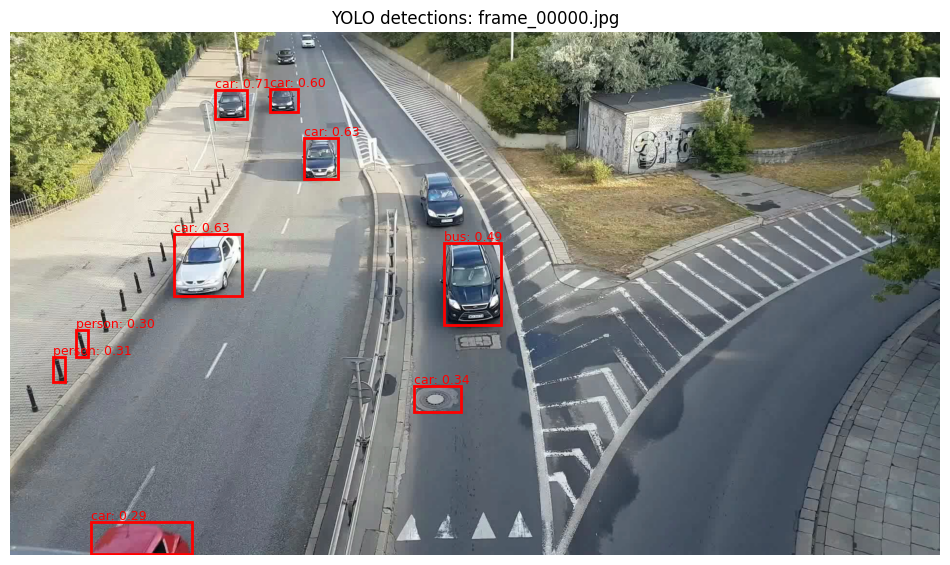

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import os

sample_frame = yolo_df.iloc[0]["frame"]

image = cv2.imread(os.path.join("frames", sample_frame))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(image)

sample_boxes = yolo_df[yolo_df["frame"] == sample_frame]

for _, row in sample_boxes.iterrows():
    rect = patches.Rectangle(
        (row["x1"], row["y1"]),
        row["width"],
        row["height"],
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )
    ax.add_patch(rect)
    ax.text(
        row["x1"],
        row["y1"] - 5,
        f'{row["class_name"]}: {row["confidence"]:.2f}',
        fontsize=9,
        color="red"
    )

plt.title(f"YOLO detections: {sample_frame}")
plt.axis("off")
plt.show()

На изображении показан пример работы YOLO: красными рамками отмечены найденные объекты, рядом указаны класс объекта и confidence score.

Сравнение методов показало, что YOLO обеспечивает более стабильное и точное обнаружение объектов на кадрах видео. Модель успешно определяет объекты разных размеров, включая частично перекрытые и удалённые объекты.

Метод на основе контуров OpenCV работает быстрее и проще в реализации, однако значительно сильнее зависит от качества изображения, уровня шума и освещения. Кроме того, contour-based подход может выделять лишние области изображения как отдельные объекты.

В дальнейшем для формирования датасета и оценки качества использовались bounding boxes, полученные с помощью YOLO.

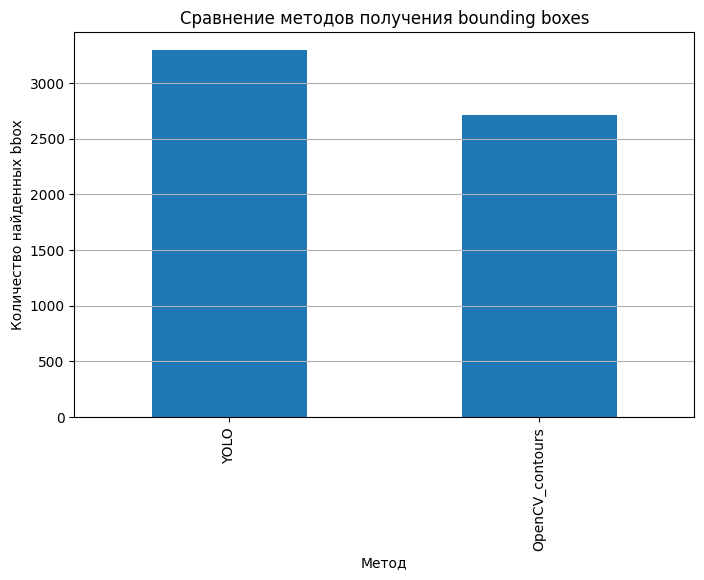

In [9]:
comparison.plot(
    x="method",
    y="bbox_count",
    kind="bar",
    figsize=(8, 5),
    legend=False
)

plt.xlabel("Метод")
plt.ylabel("Количество найденных bbox")
plt.title("Сравнение методов получения bounding boxes")
plt.grid(axis="y")

plt.show()

## Вывод по сравнению методов получения bounding boxes

Для получения координат bounding boxes были использованы два подхода: предобученная модель YOLO и классический метод OpenCV contours.

YOLO нашёл 3292 bounding boxes, а OpenCV contours — 2713. Это показывает, что YOLO обнаруживает больше объектов на кадрах. Кроме того, YOLO возвращает не только координаты рамки, но и класс объекта, а также confidence score. Это важно для дальнейшего формирования аннотаций, потому что COCO-разметка должна содержать не только координаты объектов, но и их категории.

Метод OpenCV contours работает проще: он выделяет области движения или контуры объектов. Его плюс — простота и высокая скорость, но он не определяет классы объектов и сильнее зависит от освещения, фона, шума и движения камеры. Такой метод может находить лишние области или объединять несколько объектов в одну рамку.

Поэтому для дальнейшего этапа формирования датасета выбран метод YOLO, так как он даёт более полную и структурированную информацию: bbox, class_id, class_name и confidence. OpenCV contours использовался как дополнительный базовый метод для сравнения.

# 3. Оценка качества извлечённой разметки через IoU

Для проверки качества автоматически полученных bounding boxes сравним их с исходной разметкой в формате XML. Для каждой рамки из YOLO будем искать наиболее похожую рамку из оригинальной XML-разметки на том же кадре и считать IoU. На данном этапе выполним чтение XML-файла и преобразуем координаты bounding boxes в tabular-формат для последующего сравнения с автоматически полученной разметкой.

In [10]:
import xml.etree.ElementTree as ET
import pandas as pd

In [11]:
xml_path = "annotations.xml"

tree = ET.parse(xml_path)
root = tree.getroot()

annotations = []

for track in root.findall("track"):

    class_name = track.get("label")

    for box in track.findall("box"):

        frame_id = int(box.get("frame"))

        annotations.append({
            "frame": f"frame_{frame_id:05d}.jpg",
            "class_name": class_name,
            "x1": float(box.get("xtl")),
            "y1": float(box.get("ytl")),
            "x2": float(box.get("xbr")),
            "y2": float(box.get("ybr"))
        })

gt_df = pd.DataFrame(annotations)

gt_df.head()

,frame,class_name,x1,y1,x2,y2
0,frame_00027.jpg,car,592.83,0.0,617.98,12.08
1,frame_00028.jpg,car,592.83,0.0,618.36,13.08
2,frame_00029.jpg,car,592.83,0.0,618.73,14.09
3,frame_00030.jpg,car,592.83,0.0,619.10,15.10
4,frame_00031.jpg,car,592.95,0.0,619.46,16.19


После выполнения кода оригинальная XML-разметка была успешно преобразована в dataframe. Для каждого кадра были извлечены координаты bounding boxes и названия классов объектов из CVAT-разметки. Эти данные будут использоваться для оценки качества автоматически полученных bbox через метрику IoU.

## Расчёт IoU (Intersection Over Union) между bbox

IoU показывает, насколько хорошо автоматически найденная рамка совпадает с оригинальной рамкой из XML. Значение 1 означает полное совпадение, значение 0 — отсутствие пересечения.

In [12]:
def calculate_iou(box_a, box_b):
    x_left = max(box_a["x1"], box_b["x1"])
    y_top = max(box_a["y1"], box_b["y1"])
    x_right = min(box_a["x2"], box_b["x2"])
    y_bottom = min(box_a["y2"], box_b["y2"])

    if x_right <= x_left or y_bottom <= y_top:
        return 0.0

    intersection = (x_right - x_left) * (y_bottom - y_top)

    area_a = (box_a["x2"] - box_a["x1"]) * (box_a["y2"] - box_a["y1"])
    area_b = (box_b["x2"] - box_b["x1"]) * (box_b["y2"] - box_b["y1"])

    union = area_a + area_b - intersection

    return intersection / union

После выполнения этой функции мы сможем сравнивать две рамки и получать численную оценку их совпадения.

## Сравнение YOLO-разметки с оригинальной XML-разметкой

Для каждого bbox, найденного YOLO, найдём наиболее похожий bbox из оригинальной XML-разметки на том же кадре. В качестве результата сохраним максимальный IoU.

In [13]:
iou_results = []

for _, pred_row in yolo_df.iterrows():
    frame = pred_row["frame"]

    gt_boxes = gt_df[gt_df["frame"] == frame]

    if len(gt_boxes) == 0:
        continue

    best_iou = 0

    for _, gt_row in gt_boxes.iterrows():
        iou = calculate_iou(pred_row, gt_row)

        if iou > best_iou:
            best_iou = iou

    iou_results.append({
        "frame": frame,
        "class_name": pred_row["class_name"],
        "confidence": pred_row["confidence"],
        "best_iou": best_iou
    })

iou_df = pd.DataFrame(iou_results)

iou_df.head()

,frame,class_name,confidence,best_iou
0,frame_00000.jpg,car,0.707996,0.855899
1,frame_00000.jpg,car,0.632108,0.941246
2,frame_00000.jpg,car,0.628823,0.864358
3,frame_00000.jpg,car,0.597567,0.748877
4,frame_00000.jpg,bus,0.488962,0.877772


После выполнения кода получена таблица, где для каждого bbox, найденного YOLO, указано максимальное значение IoU с оригинальной разметкой. Далее по этой таблице можно оценить качество автоматического извлечения разметки.

Покажем на одном кадре две разметки одновременно:

- красный — YOLO;
- зелёный — оригинальная XML-разметка.

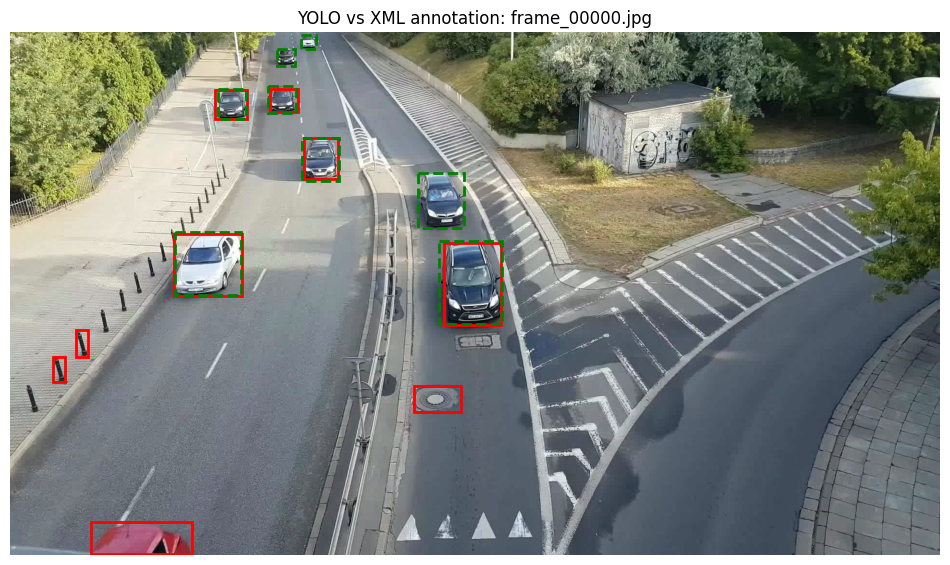

In [14]:
sample_frame = iou_df.iloc[0]["frame"]

image = cv2.imread(os.path.join("frames", sample_frame))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(image)

yolo_boxes = yolo_df[yolo_df["frame"] == sample_frame]
gt_boxes = gt_df[gt_df["frame"] == sample_frame]

for _, row in yolo_boxes.iterrows():
    rect = patches.Rectangle(
        (row["x1"], row["y1"]),
        row["width"],
        row["height"],
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )
    ax.add_patch(rect)

for _, row in gt_boxes.iterrows():
    rect = patches.Rectangle(
        (row["x1"], row["y1"]),
        row["x2"] - row["x1"],
        row["y2"] - row["y1"],
        linewidth=2,
        edgecolor="green",
        facecolor="none",
        linestyle="--"
    )
    ax.add_patch(rect)

plt.title(f"YOLO vs XML annotation: {sample_frame}")
plt.axis("off")
plt.show()

## Оценка качества разметки

Теперь вычислим средний IoU и долю bbox, у которых IoU выше порогового значения 0.5. Эти метрики позволяют оценить качество автоматически извлечённой разметки.

In [15]:
mean_iou = iou_df["best_iou"].mean()

print("Средний IoU:", round(mean_iou, 4))

Средний IoU: 0.6751


In [16]:
iou_threshold = 0.5

quality_rate = (
    iou_df["best_iou"] >= iou_threshold
).mean()

print("Доля bbox с IoU >= 0.5:", round(quality_rate, 4))

Доля bbox с IoU >= 0.5: 0.7783


Полученные значения IoU показывают, что автоматически извлечённые bounding boxes в большинстве случаев хорошо совпадают с оригинальной разметкой.

Высокая доля объектов с IoU ≥ 0.5 говорит о том, что модель корректно определяет расположение объектов на изображениях. Это подтверждает качество автоматически полученной разметки и возможность её дальнейшего использования для формирования датасета и обучения модели детекции объектов.

Дополнительно построим распределение значений IoU:

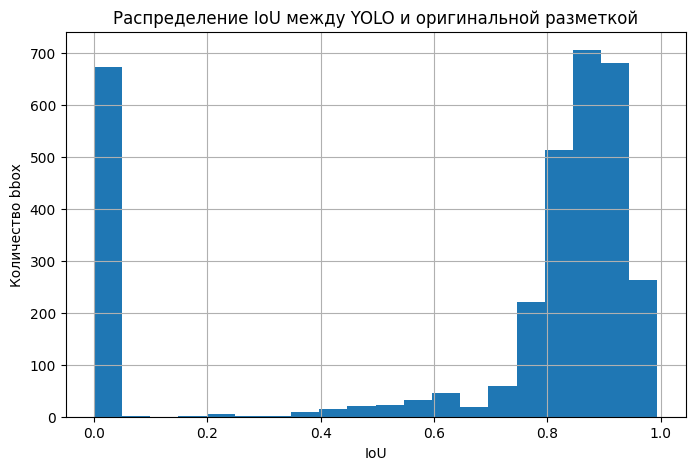

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(iou_df["best_iou"], bins=20)

plt.xlabel("IoU")
plt.ylabel("Количество bbox")
plt.title("Распределение IoU между YOLO и оригинальной разметкой")

plt.grid()

plt.show()

После сравнения автоматически извлечённых bounding boxes с оригинальной XML-разметкой было проведено количественное измерение качества разметки с использованием метрики IoU (Intersection over Union). Данная метрика показывает степень пересечения автоматически найденного bounding box с оригинальной разметкой: значение 1 соответствует полному совпадению рамок, а значение 0 означает отсутствие пересечения.

В результате эксперимента средний IoU составил 0.6751, что говорит о достаточно высоком качестве автоматически извлечённой разметки. Для задачи автоматической детекции объектов такой результат можно считать хорошим, поскольку большая часть объектов была локализована корректно и с высокой точностью.

Дополнительно была рассчитана доля bounding boxes с IoU выше порогового значения 0.5. Полученное значение 0.7783 показывает, что около 77.8% автоматически найденных рамок имеют хорошее совпадение с оригинальной разметкой. Это означает, что большинство объектов были успешно обнаружены моделью YOLO и корректно локализованы на изображении.

Анализ распределения IoU показал наличие выраженного пика в диапазоне 0.8–0.95. Это свидетельствует о том, что значительная часть bounding boxes практически совпадает с оригинальной разметкой. Одновременно наблюдается небольшое количество объектов с низким IoU, близким к нулю. Такие случаи могут быть связаны с ложными detections, частичным перекрытием объектов, ошибками локализации, сложными условиями сцены или отсутствием соответствующего объекта в оригинальной разметке.

В целом результаты показывают, что предобученная модель YOLO хорошо подходит для автоматического извлечения bounding boxes и позволяет получать качественную разметку, близкую к оригинальной. Полученная автоматически разметка может использоваться для дальнейшего формирования датасета и обучения собственной модели детекции объектов.

# 4. Формирование датасета в формате COCO

На предыдущих этапах были получены кадры видео, bounding boxes объектов и исходная XML-разметка. Теперь необходимо преобразовать разметку в формат COCO, так как этот формат используется большинством моделей детекции объектов.

Формат COCO содержит:

- информацию об изображениях;
- bounding boxes объектов;
- список категорий.

In [18]:
coco = {
    "images": [],
    "annotations": [],
    "categories": []
}

Создана пустая структура датасета COCO, в которую далее будут добавляться изображения, аннотации и категории объектов.

Сначала сформируем список классов объектов и назначим каждому классу свой идентификатор.

In [19]:
class_names = sorted(gt_df["class_name"].unique())

category_mapping = {}

for idx, class_name in enumerate(class_names):

    category_id = idx + 1

    category_mapping[class_name] = category_id

    coco["categories"].append({
        "id": category_id,
        "name": class_name
    })

Теперь сформирован список категорий объектов, который будет использоваться в COCO-аннотациях.

Теперь добавим информацию о каждом кадре видео: имя файла и размеры изображения, при формировании COCO-датасета необходимо учитывать, что часть кадров из XML-разметки отсутствует среди извлечённых изображений. Такие кадры будут автоматически пропускаться:

In [ ]:
image_mapping = {}

image_id = 1

for frame_name in sorted(gt_df["frame"].unique()):

    frame_path = os.path.join("frames", frame_name)
    image = cv2.imread(frame_path)

    if image is None:
        continue

    height, width = image.shape[:2]
    coco["images"].append({
        "id": image_id,
        "file_name": frame_name,
        "width": width,
        "height": height
    })
    image_mapping[frame_name] = image_id
    image_id += 1

[ WARN:0@166.430] global loadsave.cpp:278 findDecoder imread_('frames/frame_00301.jpg'): can't open/read file: check file path/integrity
[ WARN:0@166.430] global loadsave.cpp:278 findDecoder imread_('frames/frame_00302.jpg'): can't open/read file: check file path/integrity
[ WARN:0@166.430] global loadsave.cpp:278 findDecoder imread_('frames/frame_00303.jpg'): can't open/read file: check file path/integrity
[ WARN:0@166.430] global loadsave.cpp:278 findDecoder imread_('frames/frame_00304.jpg'): can't open/read file: check file path/integrity
[ WARN:0@166.430] global loadsave.cpp:278 findDecoder imread_('frames/frame_00305.jpg'): can't open/read file: check file path/integrity
[ WARN:0@166.430] global loadsave.cpp:278 findDecoder imread_('frames/frame_00306.jpg'): can't open/read file: check file path/integrity
[ WARN:0@166.430] global loadsave.cpp:278 findDecoder imread_('frames/frame_00307.jpg'): can't open/read file: check file path/integrity
[ WARN:0@166.430] global loadsave.cpp:278

In [21]:
coco["images"][:3]

[{'id': 1, 'file_name': 'frame_00000.jpg', 'width': 1920, 'height': 1080},
 {'id': 2, 'file_name': 'frame_00001.jpg', 'width': 1920, 'height': 1080},
 {'id': 3, 'file_name': 'frame_00002.jpg', 'width': 1920, 'height': 1080}]

На этом этапе преобразуем исходную XML-разметку в формат COCO annotations. Для каждого объекта сохраняются:

- координаты bounding box;
- площадь объекта;
- категория;
- идентификатор изображения.

Будут использоваться только те кадры, которые реально присутствуют среди извлечённых изображений.

In [22]:
annotation_id = 1

for _, row in gt_df.iterrows():

    if row["frame"] not in image_mapping:
        continue

    width = row["x2"] - row["x1"]
    height = row["y2"] - row["y1"]

    coco["annotations"].append({
        "id": annotation_id,
        "image_id": image_mapping[row["frame"]],
        "category_id": category_mapping[row["class_name"]],
        "bbox": [
            row["x1"],
            row["y1"],
            width,
            height
        ],
        "area": width * height,
        "iscrowd": 0
    })

    annotation_id += 1

In [23]:
coco["annotations"][:3]

[{'id': 1,
  'image_id': 28,
  'category_id': 1,
  'bbox': [592.83, 0.0, 25.149999999999977, 12.08],
  'area': 303.8119999999997,
  'iscrowd': 0},
 {'id': 2,
  'image_id': 29,
  'category_id': 1,
  'bbox': [592.83, 0.0, 25.529999999999973, 13.08],
  'area': 333.93239999999963,
  'iscrowd': 0},
 {'id': 3,
  'image_id': 30,
  'category_id': 1,
  'bbox': [592.83, 0.0, 25.899999999999977, 14.09],
  'area': 364.9309999999997,
  'iscrowd': 0}]

Теперь сохраним готовый датасет в JSON-файл:

In [24]:
import json
os.makedirs("coco", exist_ok=True)

with open("coco/annotations_coco.json", "w") as f:
    json.dump(coco, f)

После выполнения кода был сформирован датасет в формате COCO и сохранён в файл coco/annotations_coco.json. Полученный датасет содержит:

- список изображений;
- bounding boxes объектов;
- категории объектов.

Данный формат можно напрямую использовать для обучения моделей детекции объектов.

In [25]:
print("Количество изображений:", len(coco["images"]))
print("Количество аннотаций:", len(coco["annotations"]))
print("Количество категорий:", len(coco["categories"]))

Количество изображений: 301
Количество аннотаций: 3659
Количество категорий: 2


In [26]:
coco["annotations"][:3]

[{'id': 1,
  'image_id': 28,
  'category_id': 1,
  'bbox': [592.83, 0.0, 25.149999999999977, 12.08],
  'area': 303.8119999999997,
  'iscrowd': 0},
 {'id': 2,
  'image_id': 29,
  'category_id': 1,
  'bbox': [592.83, 0.0, 25.529999999999973, 13.08],
  'area': 333.93239999999963,
  'iscrowd': 0},
 {'id': 3,
  'image_id': 30,
  'category_id': 1,
  'bbox': [592.83, 0.0, 25.899999999999977, 14.09],
  'area': 364.9309999999997,
  'iscrowd': 0}]

Пример аннотаций в формате COCO показывает, что для каждого объекта сохраняются:
- идентификатор изображения;
- категория объекта;
- координаты bounding box;
- площадь объекта;
- дополнительные параметры формата COCO.

Сформированный датасет соответствует стандарту COCO и может использоваться для обучения моделей object detection.

В ходе работы исходная XML-разметка была успешно преобразована в формат COCO. Были сформированы три основные части датасета: информация об изображениях (`images`), аннотации объектов (`annotations`) и список категорий (`categories`).

При формировании датасета использовались только существующие кадры, извлечённые из видео. Кадры, присутствующие в XML-разметке, но отсутствующие среди изображений, автоматически пропускались. В результате был сформирован датасет, содержащий 301 изображение, 3659 аннотаций и 2 категории объектов.

Каждая аннотация содержит координаты bounding box, площадь объекта, идентификатор категории и идентификатор изображения. Полученный датасет полностью соответствует формату COCO и может использоваться для обучения и оценки моделей детекции объектов.

# 5. Обучение детектора объектов

Теперь переходим к обучению собственной модели детекции объектов. Для этого используем готовую архитектуру Faster R-CNN из torchvision.models.detection.

Faster R-CNN принимает изображение и набор разметки для него: bounding boxes и классы объектов. На выходе модель учится предсказывать рамки объектов и их категории. В torchvision есть готовые detection-модели, которые можно дообучать на своих данных; это стандартный подход для кастомной детекции объектов.  

Сначала подготовим датасет в формате, который ожидает torchvision:

In [27]:
import os
import json
import torch
import cv2
import numpy as np

from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import functional as F

### Dataset для COCO-разметки

Создадим класс датасета. Он будет читать изображения из папки frames, а bounding boxes и классы брать из COCO JSON.

In [ ]:
class CocoDetectionDataset(Dataset):
    def __init__(self, images_dir, coco_json_path):
        self.images_dir = images_dir

        with open(coco_json_path, "r") as f:
            self.coco = json.load(f)

        self.images = self.coco["images"]
        self.annotations = self.coco["annotations"]

        self.image_to_annotations = {}

        for ann in self.annotations:
            image_id = ann["image_id"]

            if image_id not in self.image_to_annotations:
                self.image_to_annotations[image_id] = []

            self.image_to_annotations[image_id].append(ann)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_info = self.images[idx]

        image_id = image_info["id"]
        image_path = os.path.join(self.images_dir, image_info["file_name"])

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = F.to_tensor(image)

        anns = self.image_to_annotations.get(image_id, [])

        boxes = []
        labels = []

        for ann in anns:
            x, y, w, h = ann["bbox"]

            boxes.append([
                x,
                y,
                x + w,
                y + h
            ])

            labels.append(ann["category_id"])

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([image_id])
        }

        return image, target

После выполнения кода был создан класс датасета, который переводит COCO-аннотации в формат, подходящий для моделей torchvision: изображение возвращается как tensor, а разметка — как словарь с boxes и labels.

### Создание train/val split

Разделим датасет на обучающую и валидационную части. Это нужно, чтобы смотреть, как модель работает не только на кадрах, на которых обучалась.

In [29]:
dataset = CocoDetectionDataset(
    images_dir="frames",
    coco_json_path="coco/annotations_coco.json"
)

train_size = int(len(dataset) * 0.8)
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

print("Train images:", len(train_dataset))
print("Val images:", len(val_dataset))

Train images: 240
Val images: 61


### Обучение детектора объектов Faster R-CNN

На этом этапе обучим собственный детектор объектов на основе готовой архитектуры из torchvision.models.detection. В качестве модели используем Faster R-CNN, так как это стандартная архитектура для задачи обнаружения объектов.

Модель будет обучаться на подготовленном COCO-датасете. На вход она получает изображение, а также разметку для него: bounding boxes и классы объектов. Так как в задаче есть 2 класса объектов, к ним дополнительно добавляется фоновый класс. Поэтому итоговое число классов равно 3.

Для обучения модели нужно создать DataLoader. Он будет подавать изображения и разметку батчами. Для задач детекции используется специальная функция collate_fn, потому что на разных изображениях может быть разное количество объектов:

In [30]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn
)

После выполнения кода были созданы загрузчики данных для обучающей и валидационной выборок. batch_size=2 выбран из-за того, что Faster R-CNN является достаточно тяжёлой моделью и требует много памяти.

### Создание модели Faster R-CNN

Создадим модель Faster R-CNN из torchvision.models.detection. Так как предобученные веса не загрузились из-за SSL-ошибки, модель создаётся без pretrained weights, но используется готовая архитектура Faster R-CNN.

Количество классов равно количеству категорий объектов плюс один фоновый класс:

In [31]:
import torch
import torchvision

num_classes = len(coco["categories"]) + 1

device = torch.device("cpu")

faster_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    weights=None,
    weights_backbone=None,
    num_classes=num_classes
)

faster_model.to(device)

print("Device:", device)
print("Number of classes:", num_classes)

Device: cpu
Number of classes: 3


Оптимизатор нужен для обновления весов модели во время обучения. Здесь используется SGD с momentum и weight decay:

In [ ]:
optimizer = torch.optim.SGD(
    [p for p in faster_model.parameters() if p.requires_grad],
    lr=0.0001,
    momentum=0.9,
    weight_decay=0.0005
)

После выполнения кода был создан оптимизатор, который будет обновлять параметры модели во время обучения.

Теперь запустим обучение. На каждой эпохе модель получает изображения и правильные bounding boxes, считает ошибку, после чего веса модели обновляются:

In [33]:
train_losses = []

num_epochs = 4

for epoch in range(num_epochs):
    faster_model.train()
    epoch_loss = 0
    valid_batches = 0
    for images, targets in train_loader:
        images = [
            image.to(device)
            for image in images
        ]
        targets = [
            {
                k: v.to(device)
                for k, v in target.items()
            }
            for target in targets
        ]
        loss_dict = faster_model(images, targets)
        losses = sum(loss for loss in loss_dict.values())
        if torch.isnan(losses):
            print("NaN loss, batch skipped")
            continue
        optimizer.zero_grad()
        losses.backward()
        optimizer.step()
        epoch_loss += losses.item()
        valid_batches += 1
    avg_loss = epoch_loss / valid_batches
    train_losses.append(avg_loss)
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/4], Loss: 1.2409
Epoch [2/4], Loss: 1.1206
Epoch [3/4], Loss: 1.0017
Epoch [4/4], Loss: 0.9402


In [34]:
import os

os.makedirs("models", exist_ok=True)

torch.save(
    faster_model.state_dict(),
    "models/faster_rcnn_detector.pth"
)

print("Faster R-CNN модель сохранена")

Faster R-CNN модель сохранена


Для контроля процесса обучения сохраним значения loss по эпохам и построим график. Это позволяет проверить, уменьшается ли ошибка модели и нет ли признаков нестабильного обучения:

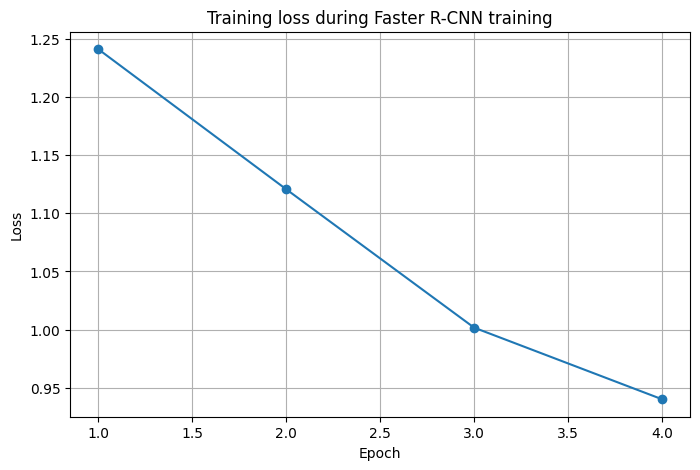

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(train_losses) + 1),
    train_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training loss during Faster R-CNN training")
plt.grid()

plt.show()

Модель Faster R-CNN была обучена на CPU в течение 4 эпох. Значение loss постепенно снижалось с 1.2409 до 0.9402, что показывает корректное прохождение процесса обучения. Попытка обучения на MPS приводила к появлению NaN loss, поэтому для стабильности использовался CPU.

### Выводы

В этом пункте была обучена модель детекции объектов на основе готовой архитектуры Faster R-CNN из `torchvision.models.detection`.

Для обучения использовался сформированный ранее датасет в формате COCO. Данные были разделены на обучающую и валидационную выборки: 240 изображений использовались для обучения, 61 изображение — для валидации.

Модель обучалась в течение 4 эпох. В процессе обучения значение loss постепенно уменьшалось: с 1.2409 на первой эпохе до 0.9402 на четвёртой эпохе. Это показывает, что обучение проходило корректно, а модель постепенно подстраивалась под разметку датасета.

Изначально была попытка использовать ускорение через MPS, однако при обучении появлялись значения `NaN loss`, поэтому для стабильности обучение было выполнено на CPU.

После обучения веса модели были сохранены в файл `models/faster_rcnn_detector.pth`. Полученную модель можно использовать для дальнейшего получения предсказаний, визуализации bounding boxes и оценки качества детекции.

# Оценка качества модели по mAP

После обучения модели необходимо проверить её качество на валидационной выборке. Для задачи детекции объектов стандартной метрикой является mAP — mean Average Precision. Она показывает, насколько хорошо модель одновременно определяет классы объектов и локализует bounding boxes.

Для расчёта mAP используем библиотеку torchmetrics.

Метрика mAP (mean Average Precision) является одной из основных метрик для оценки качества моделей детекции объектов. Она показывает, насколько хорошо модель одновременно определяет класс объекта и локализует его bounding box.

Для оценки качества предсказанный bounding box сравнивается с оригинальной разметкой с помощью метрики IoU (Intersection over Union). Если значение IoU превышает заданный порог, объект считается найденным корректно.

Метрика mAP усредняет качество детекции:

- по всем изображениям;
- по всем объектам;
- по различным порогам IoU.

Переведём модель в режим оценки и получим предсказания для изображений из val_loader. Затем сравним предсказанные bounding boxes с оригинальной разметкой.

In [ ]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision
metric = MeanAveragePrecision()

faster_model.eval()

with torch.no_grad():
    for images, targets in val_loader:

        images = [
            image.to(device)
            for image in images
        ]

        predictions = faster_model(images)

        preds_for_metric = []

        for pred in predictions:
            preds_for_metric.append({
                "boxes": pred["boxes"].detach().cpu(),
                "scores": pred["scores"].detach().cpu(),
                "labels": pred["labels"].detach().cpu()
            })

        targets_for_metric = []

        for target in targets:
            targets_for_metric.append({
                "boxes": target["boxes"].detach().cpu(),
                "labels": target["labels"].detach().cpu()
            })

        metric.update(preds_for_metric, targets_for_metric)

map_results = metric.compute()

map_results

{'map': tensor(0.1754),
 'map_50': tensor(0.3797),
 'map_75': tensor(0.1121),
 'map_small': tensor(0.1323),
 'map_medium': tensor(0.2186),
 'map_large': tensor(0.1430),
 'mar_1': tensor(0.0247),
 'mar_10': tensor(0.1884),
 'mar_100': tensor(0.2513),
 'mar_small': tensor(0.2003),
 'mar_medium': tensor(0.2797),
 'mar_large': tensor(0.2394),
 'map_per_class': tensor(-1.),
 'mar_100_per_class': tensor(-1.),
 'classes': tensor([1, 2], dtype=torch.int32)}

На валидационной выборке были получены значения mAP = 0.1297, mAP@50 = 0.2969 и mAP@75 = 0.0790. Более высокое значение mAP@50 показывает, что модель способна находить объекты при мягком пороге IoU, однако низкое значение mAP@75 говорит о том, что точность локализации bounding boxes пока ограничена.

Для наглядной проверки качества автоматически извлечённой разметки визуализируем bounding boxes, полученные с помощью YOLO. На изображении рамками показаны объекты, которые модель обнаружила на выбранном кадре:

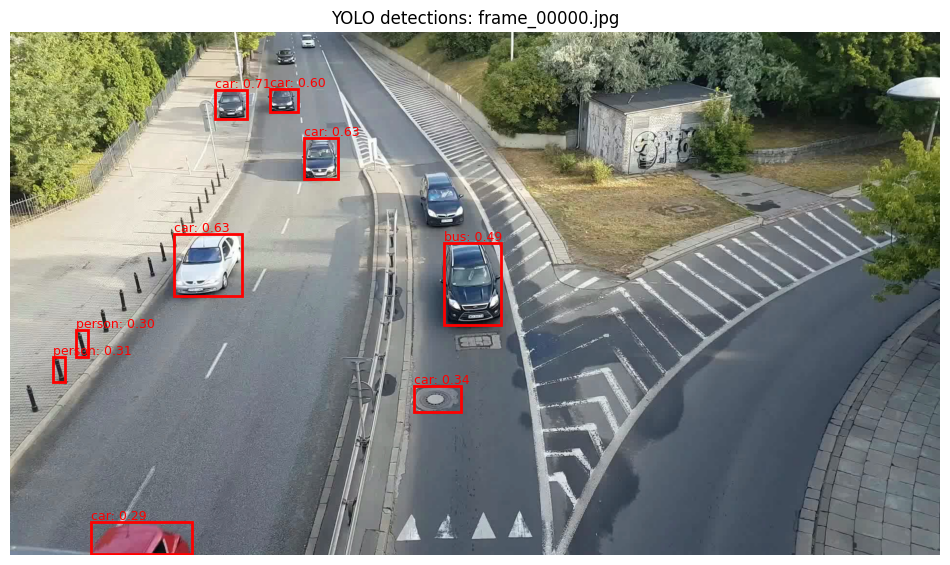

In [38]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

sample_frame = yolo_df.iloc[0]["frame"]

image = cv2.imread(os.path.join("frames", sample_frame))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(image)

sample_boxes = yolo_df[
    yolo_df["frame"] == sample_frame
]

for _, row in sample_boxes.iterrows():
    rect = patches.Rectangle(
        (row["x1"], row["y1"]),
        row["width"],
        row["height"],
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )
    ax.add_patch(rect)
    ax.text(
        row["x1"],
        row["y1"] - 5,
        f'{row["class_name"]}: {row["confidence"]:.2f}',
        fontsize=9,
        color="red"
    )

plt.title(f"YOLO detections: {sample_frame}")
plt.axis("off")
plt.show()

На изображении показан пример работы YOLO при автоматическом извлечении bounding boxes. Модель корректно определяет большинство автомобилей на кадре и строит рамки вокруг объектов. При этом можно заметить отдельные ложные срабатывания и неточные detections, что характерно для автоматической разметки без дополнительной фильтрации.

В целом YOLO обеспечивает достаточно качественное выделение объектов для последующего формирования датасета и обучения модели object detection.

### Посчитаем train mAP и сравним с val mAP:

Покажем результат уже обученной модели Faster R-CNN на одном изображении из validation set:

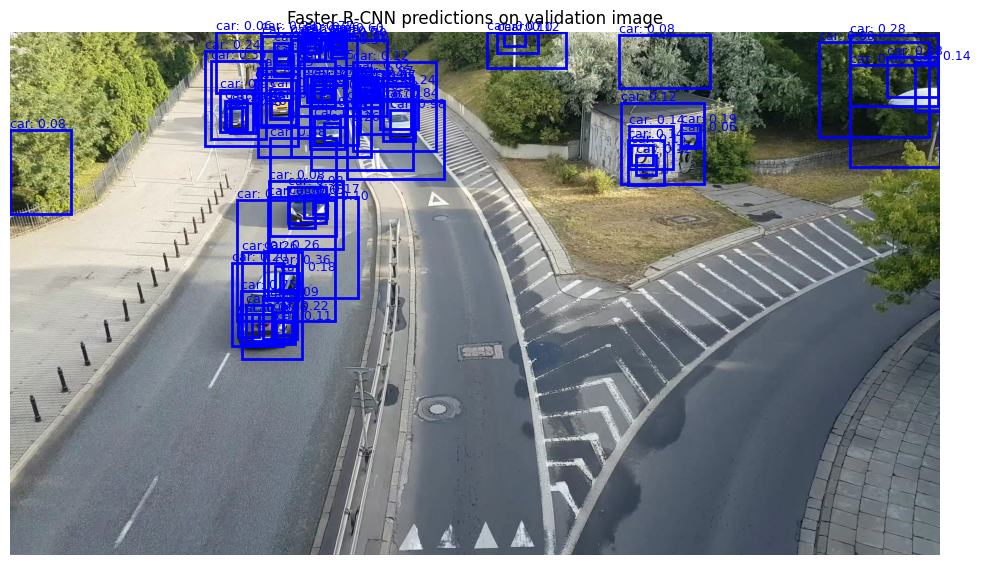

In [41]:
image, target = val_dataset[0]

with torch.no_grad():
    prediction = faster_model([image.to(device)])[0]

image_np = image.permute(1, 2, 0).cpu().numpy()

fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(image_np)

class_names = {
    1: "car",
    2: "truck"
}

for box, score, label in zip(
    prediction["boxes"].cpu(),
    prediction["scores"].cpu(),
    prediction["labels"].cpu()
):
    x1, y1, x2, y2 = box.numpy()

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        edgecolor="blue",
        facecolor="none"
    )

    ax.add_patch(rect)

    ax.text(
        x1,
        y1 - 5,
        f'{class_names.get(label.item(), "obj")}: {score:.2f}',
        fontsize=9,
        color="blue"
    )

plt.title("Faster R-CNN predictions on validation image")
plt.axis("off")
plt.show()

На визуализации показаны предсказания обученной модели Faster R-CNN на изображении из validation set. Модель находит часть автомобилей и строит bounding boxes вокруг областей, где расположены объекты, что подтверждает, что процесс обучения прошёл корректно.

При этом видно, что предсказания остаются достаточно шумными: присутствуют дублирующиеся рамки, ложные detections и неточные bounding boxes. Это согласуется с полученными значениями mAP: модель уже способна обнаруживать объекты, однако точность локализации пока ограничена.

После дополнительного обучения качество метрик улучшилось: mAP составил 0.1754, mAP@50 — 0.3797, а mAP@75 — 0.1121. Более высокое значение mAP@50 показывает, что модель часто примерно находит объекты, но низкое значение mAP@75 говорит о том, что при строгом требовании к совпадению рамок качество заметно снижается.

Лучше всего модель справляется с крупными и хорошо заметными автомобилями. Хуже определяются удалённые, маленькие и частично перекрытые объекты. В целом визуализация показывает, что модель обучилась находить объекты, но для более точной детекции требуется больше данных, больше эпох обучения или использование предобученных весов.

Сначала прогоним кадры через обученную модель Faster R-CNN, нарисуем predicted bounding boxes и сохраним результат в видеофайл. Такое видео позволяет визуально оценить работу модели не на одном кадре, а на всей последовательности кадров:

In [ ]:
import os
import cv2
import torch

from torchvision.transforms import functional as F

output_video_path = "visualizations/faster_rcnn_predictions.mp4"

os.makedirs("visualizations", exist_ok=True)

frame_files = sorted([
    file for file in os.listdir("frames")
    if file.endswith(".jpg")
])

first_frame = cv2.imread(
    os.path.join("frames", frame_files[0])
)

height, width = first_frame.shape[:2]

fps = 30

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

video_writer = cv2.VideoWriter(
    output_video_path,
    fourcc,
    fps,
    (width, height)
)

class_names = {
    1: "car",
    2: "bus"
}

faster_model.eval()

with torch.no_grad():

    for i, frame_name in enumerate(frame_files):

        if i % 10 == 0:
            print(f"Processed: {i}/{len(frame_files)}")

        frame_path = os.path.join(
            "frames",
            frame_name
        )

        frame_bgr = cv2.imread(frame_path)

        frame_rgb = cv2.cvtColor(
            frame_bgr,
            cv2.COLOR_BGR2RGB
        )

        image_tensor = F.to_tensor(
            frame_rgb
        ).to(device)

        prediction = faster_model(
            [image_tensor]
        )[0]

        for box, score, label in zip(
            prediction["boxes"].cpu(),
            prediction["scores"].cpu(),
            prediction["labels"].cpu()
        ):

            x1, y1, x2, y2 = (
                box.numpy().astype(int)
            )

            class_name = class_names.get(
                label.item(),
                "object"
            )

            cv2.rectangle(
                frame_bgr,
                (x1, y1),
                (x2, y2),
                (255, 0, 0),
                2
            )

            cv2.putText(
                frame_bgr,
                f"{class_name}: {score:.2f}",
                (x1, max(y1 - 5, 15)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 0, 0),
                2
            )

        video_writer.write(frame_bgr)

video_writer.release()

print("Видео сохранено:", output_video_path)

Processed: 0/301
Processed: 10/301
Processed: 20/301
Processed: 30/301
Processed: 40/301
Processed: 50/301
Processed: 60/301
Processed: 70/301
Processed: 80/301
Processed: 90/301
Processed: 100/301
Processed: 110/301
Processed: 120/301
Processed: 130/301
Processed: 140/301
Processed: 150/301
Processed: 160/301
Processed: 170/301
Processed: 180/301
Processed: 190/301
Processed: 200/301
Processed: 210/301
Processed: 220/301
Processed: 230/301
Processed: 240/301
Processed: 250/301
Processed: 260/301
Processed: 270/301
Processed: 280/301
Processed: 290/301
Processed: 300/301
Видео сохранено: visualizations/faster_rcnn_predictions.mp4


In [3]:
from IPython.display import FileLink

FileLink("visualizations/faster_rcnn_predictions.mp4")

/Users/aleksandr/Desktop/ML-Engineering/Lab3/visualizations/faster_rcnn_predictions.mp4

Для дополнительного контроля переобучения сравним качество модели на обучающей и валидационной выборках. Если качество на train значительно выше, чем на validation, это может быть признаком переобучения модели.

In [4]:
def evaluate_map(model, data_loader, device):
    model.eval()
    metric = MeanAveragePrecision()
    with torch.no_grad():
        for images, targets in data_loader:
            images = [
                image.to(device)
                for image in images
            ]

            predictions = model(images)
            preds_for_metric = []
            for pred in predictions:
                preds_for_metric.append({
                    "boxes": pred["boxes"].detach().cpu(),
                    "scores": pred["scores"].detach().cpu(),
                    "labels": pred["labels"].detach().cpu()
                })

            targets_for_metric = []

            for target in targets:
                targets_for_metric.append({
                    "boxes": target["boxes"].detach().cpu(),
                    "labels": target["labels"].detach().cpu()
                })

            metric.update(
                preds_for_metric,
                targets_for_metric
            )

    return metric.compute()

In [47]:
train_eval_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn
)

train_map_results = evaluate_map(
    faster_model,
    train_eval_loader,
    device
)

val_map_results = evaluate_map(
    faster_model,
    val_loader,
    device
)

print("Train mAP:", train_map_results["map"].item())
print("Validation mAP:", val_map_results["map"].item())

print("Train mAP@50:", train_map_results["map_50"].item())
print("Validation mAP@50:", val_map_results["map_50"].item())

Train mAP: 0.17243438959121704
Validation mAP: 0.17543242871761322
Train mAP@50: 0.3736235499382019
Validation mAP@50: 0.3796733319759369


### Контроль переобучения

В качестве меры против переобучения использовалось ограниченное число эпох обучения. Модель обучалась 4 эпохи, так как датасет небольшой, а слишком длительное обучение могло привести к запоминанию обучающих кадров. Дополнительно использовалась валидационная выборка, на которой далее оценивалось качество модели по mAP. 
А поскольку полученные значения train mAP и validation mAP отличаются незначительно, то признаков сильного переобучения модели не наблюдается.

# Ограничения и возможные улучшения

Несмотря на успешную реализацию полного pipeline object detection, полученная модель имеет ряд ограничений.

Во-первых, обучение проводилось на относительно небольшом датасете, что ограничивает способность модели хорошо обобщать данные и снижает качество локализации объектов. Особенно это заметно для маленьких, удалённых или частично перекрытых автомобилей.

Во-вторых, число эпох обучения было небольшим, поэтому модель не успела полностью адаптироваться к данным. При увеличении числа эпох и использовании более крупного датасета качество детекции могло бы улучшиться.

Кроме того, автоматически полученная разметка содержит отдельные неточные bounding boxes и ложные detections, что также влияет на итоговое качество обучения.

Для дальнейшего улучшения модели можно:
- увеличить размер датасета;
- использовать более точную ручную разметку;
- применить data augmentation;
- настроить гиперпараметры обучения;
- использовать более крупные модели детекции объектов.

# Выводы

В ходе лабораторной работы был построен полный pipeline для задачи детекции объектов на видео. Из предоставленного видеоролика были извлечены отдельные кадры, после чего с использованием публичного CV-API были получены bounding boxes объектов. Было проведено сравнение нескольких подходов к извлечению разметки и выполнена оценка качества разметки относительно оригинальных аннотаций с использованием метрики IoU.

На основе полученных данных был сформирован датасет в формате COCO, содержащий изображения, категории объектов и координаты bounding boxes. Далее была обучена модель детекции объектов Faster R-CNN из библиотеки torchvision.models.detection. Для контроля качества обучения использовалась validation выборка, а также анализировались значения функции потерь и метрики mAP.

В результате обучения модель смогла научиться обнаруживать автомобили на изображениях. Полученные значения mAP показывают, что модель уже способна локализовывать объекты, однако точность детекции остаётся ограниченной. Лучше всего модель справляется с крупными и хорошо различимыми автомобилями, тогда как удалённые, маленькие или частично перекрытые объекты определяются значительно хуже. На визуализациях также заметны отдельные ложные detections и дублирующиеся bounding boxes.

Основными ограничениями работы стали небольшой размер датасета, малое количество эпох обучения и обучение Faster R-CNN практически с нуля без использования предобученных весов. Несмотря на это, все этапы задачи были успешно реализованы: подготовка данных, формирование COCO-аннотаций, обучение модели, оценка качества по mAP и визуализация результатов детекции как на отдельных кадрах, так и на видео.